<a href="https://colab.research.google.com/github/Andrea-24744/Procesos-Est-casticos-/blob/main/Caminata_Aleatoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<div align="center">**Caminata aleatoria 1D**</div>

---



<div style="text-align: justify">La caminata aleatoria o paseo aleatorio o camino aleatorio, abreviado en inglés como RW (Random Walks), es una formalización matemática de la trayectoria que resulta de hacer sucesivos pasos aleatorios.</div>


<div style="text-align: justify">En su forma más general, las caminatas aleatorias son cualquier proceso aleatorio donde la posición de una partícula en cierto instante depende solo de su posición en algún instante previo y alguna variable aleatoria que determina su subsecuente dirección y la longitud de paso. Los caminos aleatorios también varían con respecto al tiempo. Casos específicos o límites de estos incluyen la caminata de un borracho, el vuelo de Lévy y el movimiento browniano.</div>


<div style="text-align: justify">Sea $X_t$ la posición del caminante en el tiempo $t$. En cada paso de tiempo, el caminante se mueve una unidad a la derecha con probabilidad $p$ o una unidad a la izquierda con probabilidad $q$. Sabemos que la suma de las probabilidades es 1, es decir, $p + q = 1$.</div>

Podemos definir una variable aleatoria $S_i$ para el $i$-ésimo paso:


$$S_i = \begin{cases}
+1 & \text{con probabilidad } p \text{ (movimiento a la derecha)}\\
-1 & \text{con probabilidad } q \text{ (movimiento a la izquierda)}
\end{cases}$$


<div align="center">
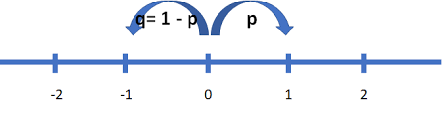
</div>

In [ ]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

def caminata(n,p):
  c =  np.random.random(n)  # Genermos aleatorios "enteros"
  for i in range(n):
    if c[i] < p:
      c[i] = 1             # Establecemos el movimiento-incremento a la derecha
    else:
      c[i] = -1            # Establecemos el movimiento-decremento a la izquierda
  posicion = np.cumsum(c)   # acumulamos los pasos
  return posicion          # Devolvemos ahora la  posiciòn nueva

In [ ]:
n = 400
p = 0.5

trayectoria = caminata(n, p) # Generamos varios eventos con probabilidad p (que modificaremos para estar analizando el comportamiento aleatorio según p)

plt.style.use('dark_background')  # Queria ponerle mi estilo a esta grafica profe, la de las 5 caminatas si esta con el fondo blanco
plt.figure(figsize=(7, 3.5))
plt.plot(trayectoria, color="cyan")
plt.xlabel("Paso n")
plt.ylabel("Posición X_n")
plt.title(f"Caminata aleatoria 1D (p={p})")
plt.grid()
plt.show()
np.mean(trayectoria)

In [ ]:
n = 400
p = 0.5

plt.figure(figsize=(9, 4.5))
for k in range(5):
    plt.plot(caminata(n, p))   # Generamos 5 caminatas

plt.style.use('default')   # Eimina el fondo negro que le habia puesto en la primera
plt.xlabel("Paso n")
plt.ylabel("Posición X_n")
plt.title(f"Caminatas con p={p}")
plt.grid()
plt.show()


##<div align="center">***Posibles preguntas***</div>

---
---

1. ¿Qué debe pasar con P para regresar al orígen?
2. Promedio en el que llega al origen
3. ¿Qué pasa cuando p aumenta?
4. ¿Qué pasa cuando p disminuye?
5. ¿Cuál es la posición promedio de la caminata?
6. Valores máximo y minimo que puede tomar











> **Análisis**







<div style="text-align: justify">Respecto a las preguntas 3 y 4 con tan solo ver la gráfica se pueden responder, puesto que al modificar los valores de p y simularlo numerosas ocasiones para ver los comportamientos, (además de ser obvio por cómo se definió el ejercicio), obtenemos que si p aumenta (q disminuye), crece drásticamente la probabilidad de avanzar a la derecha sobre la izquierda y, viceversa si p disminuye (q aumenta) entonces la probabilidad de caminar a la izquierda incrementa numerosamente. En pocas palabras si p aumenta la gráfica se dispara a la derecha y crece positivamente, si p disminuye la gráfica cae totalmente (dirección a la izquierda) y crece negativamente. Es decir, se ve de esta manera: </div>

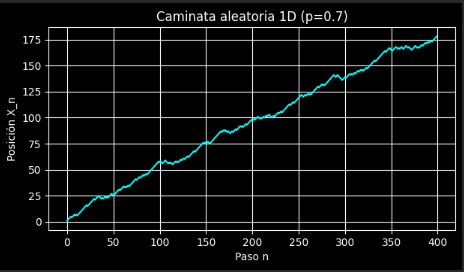

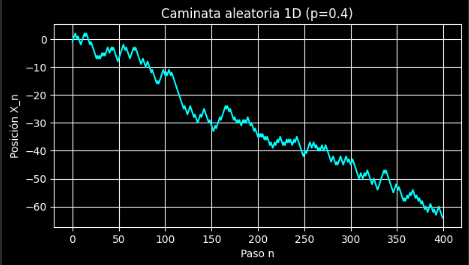


<div style="text-align: justify">En las preguntas 1, 5 y 6, también es simple razonamiento intuitivo pues para que una caminata aleatoria 1D tenga una alta probabilidad de regresar al origen, la probabilidad de moverse a la derecha $(p)$ y la probabilidad de moverse a la izquierda $(q)$ deben ser iguales, es decir, p = q = 0.5. Si p es diferente de 0.5, la caminata tenderá a desviarse del origen hacia la derecha $(\text{si} \quad p > 0.5)$ o hacia la izquierda $(\text{si} \quad p < 0.5)$. En una caminata simétrica $(p=0.5)$, se sabe que la caminata regresará al origen infinitas veces con probabilidad 1.</div>

<div style="text-align: justify">Así como los valores mínimos y máximos serán simplemente los extremos de la gráfica, según se defina el tamaño de n y la probabilidad. En el que el valor promedio no es más que la media de la trayectoria. Visualmente se tiene el siguiente código: </div>



In [ ]:
import numpy as np

# Pregunta 5: ¿Cuál es la posición promedio de la caminata?
posicion_promedio = np.mean(trayectoria)
print(f"5. La posición promedio de la caminata es: {posicion_promedio:.2f}")

# Pregunta 6: Valores máximo y mínimo que puede tomar la caminata
posicion_maxima = np.max(trayectoria)
posicion_minima = np.min(trayectoria)
print(f"6. El valor máximo alcanzado por la caminata es: {posicion_maxima}")
print(f"   El valor mínimo alcanzado por la caminata es: {posicion_minima}")

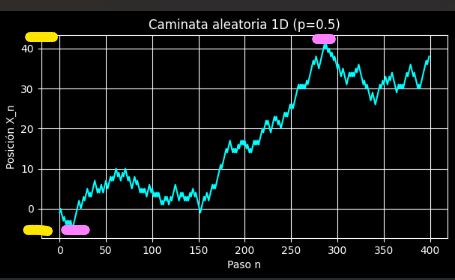


Ahora, para responder a la pregunta 2 (Promedio en el que llega al origen), necesitamos simular varias caminatas y encontrar el primer momento en que la trayectoria vuelve a 0. Esto puede ser un poco más complejo y podría no ocurrir en todas las caminatas si $p$ no es 0.5 o si el número de pasos $n$ es pequeño. Sin embargo, podemos estimarlo promediando los tiempos de retorno al origen para las caminatas que sí lo hacen.

In [ ]:
import numpy as np
import random as r

def tiempo_retorno_al_origen(num_pasos, prob_derecha, num_simulaciones_tiempo=1000):
    tiempos_retorno = []
    for _ in range(num_simulaciones_tiempo):
        posicion_actual = 0
        ha_regresado = False
        for paso in range(num_pasos):
            # Generar un movimiento aleatorio (+1 o -1)
            if r.random() < prob_derecha:
                movimiento = 1  # Movimiento a la derecha
            else:
                movimiento = -1 # Movimiento a la izquierda

            posicion_actual += movimiento

            # Verificar si ha regresado al origen
            if posicion_actual == 0:
                tiempos_retorno.append(paso + 1) # +1 porque paso es base 0
                ha_regresado = True
                break # Salir de la simulación actual una vez que regresa al origen

    if len(tiempos_retorno) > 0:
        return np.mean(tiempos_retorno)
    else:
        return float('inf') # Si nunca regresa al origen en ninguna simulación

# Parámetros de la caminata
num_pasos = 400
prob_derecha = 0.2
num_simulaciones_tiempo = 1000

# Calcular el promedio de tiempo para regresar al origen
promedio_tiempo = tiempo_retorno_al_origen(num_pasos, prob_derecha, num_simulaciones_tiempo)

print(f"\n2. El tiempo promedio para regresar al origen (basado en {num_simulaciones_tiempo} simulaciones con p={prob_derecha}) es: {promedio_tiempo:.2f} pasos (si regresa).")



> **Conclusión**

---
---

<div style="text-align: justify">En resumen, el comportamiento de una caminata aleatoria 1D es altamente sensible a la probabilidad $p$, que determina su deriva direccional. Las simulaciones permiten cuantificar aspectos como la posición promedio, los extremos alcanzados y el tiempo de retorno al origen, ofreciendo una comprensión práctica de este modelo estocástico fundamental.</div>





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as random

def caminata(p):
  c = 20
  trayectoria = [c]
  while c != 0 and c != 60:
    if np.random.random() < p:
        c += 1
    else:
        c -= 1
    trayectoria.append(c)
  return trayectoria

n= 30
p = 0.5
contador = 0
plt.figure(figsize=(13,8))
for _ in range(n):
  plt.plot(caminata(p))
  t = caminata(p)
  if t[-1] == 0:
      contador += 1

print(f"La propabilidad de que caiga en cero es:{contador/n}")

plt.style.use('dark_background')
plt.xlabel("Paso n")
plt.axhline(y = 60, color = "red")
plt.ylabel("Posición X_n")
plt.title(f"Caminatas aleatorias de ({n}) experimentos")
plt.grid()
plt.show()

Determinar por simulaciòn la distribuciòn de probabilidad P(i)

In [ ]:
plt.hist(t, bins= 26, edgecolor='black')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as random

def caminata(p):
  c = 20
  trayectoria = [c]
  while c != 0 and c != 60:
    if np.random.random() < p:
        c += 1
    else:
        c -= 1
    trayectoria.append(c)
  return trayectoria

n= 30
p = 0.5
contador = 0
plt.figure(figsize=(13,8))
for _ in range(n):
  plt.plot(caminata(p))
  t = caminata(p)
  if t[-1] == 0:
      contador += 1

print(f"La propabilidad de que caiga en cero es:{contador/n}")
